# 📘 Notebook 04: Combining Token + Positional Embeddings

This notebook shows how to combine two critical components of input processing in LLMs:

- 🧱 **Token embeddings** – What is the word?
- 📍 **Positional embeddings** – Where is the word?

The result is passed into the Transformer block as the initial input.

---


In [4]:
import torch
import torch.nn as nn

# Sample vocabulary
text = "I love AI and pizza".split()
vocab = dict(zip(text, range(0, len(text))))
vocab_size = len(vocab)
embedding_dim = 16
seq_len = 5

In [5]:
# Token embedding layer
token_embedding = nn.Embedding(num_embeddings=vocab_size,
                               embedding_dim=embedding_dim)

# Poisitional embedding layer(learned)
position_embedding = nn.Embedding(num_embeddings=seq_len,
                                  embedding_dim=embedding_dim)

## 🧪 Goal

We're creating a sentence like: `"I love AI and pizza"`  
→ Tokenized to `[0, 1, 2, 3, 4]`  
→ Get embeddings for each token  
→ Add corresponding **position embedding** (0 for "I", 1 for "love", ...)

---


In [6]:
# Sentence as token IDs
sentence = text
token_ids = torch.tensor([vocab[word] for word in sentence])

# Get token embeddings
tok_embed = token_embedding(token_ids)

# Get positions [0, 1, 2, 3, 4]
positions = torch.arange(seq_len)
pos_embed = position_embedding(positions)

# Combine them (element-wise addition)
final_embed = tok_embed + pos_embed

print(f"Final input embeddings shape : {final_embed.shape}")
print(f"Embedding for token 'AI' :\n{final_embed[2]}")  # Third token

Final input embeddings shape : torch.Size([5, 16])
Embedding for token 'AI' :
tensor([-0.3195, -2.8460,  0.1703, -2.0388, -1.5084,  0.5831, -2.5006, -0.1838,
         0.6977, -1.8416,  1.7433,  1.0309, -2.4495,  1.5845,  1.0870, -1.5473],
       grad_fn=<SelectBackward0>)


## 🔬 Why Do We Add?

Adding token + position embeddings lets the model:
- Know **what** the token is (from token vector)
- Know **where** it appears (from position vector)

This combination is fed into the **Transformer block** as the first input.

✅ Shape: `(seq_len × embedding_dim)` — ready to go!

---


Text(0, 0.5, 'Token Positions')

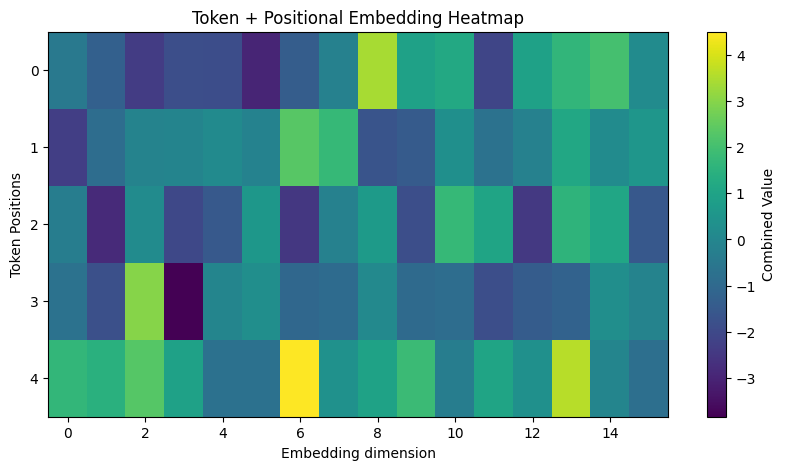

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.imshow(final_embed.detach().numpy(), aspect="auto", cmap="viridis")
plt.colorbar(label = "Combined Value")
plt.title("Token + Positional Embedding Heatmap")
plt.xlabel("Embedding dimension")
plt.ylabel("Token Positions")

## ✅ Summary

- We now have **final embeddings** ready for the Transformer input
- Each embedding contains token + position info
- This wraps up the **embedding phase** of our LLM pipeline!

---

🔭 Next up: We enter the heart of a Transformer — **Multi-Head Attention, Feed-Forward, and Residual Blocks**.

📁 Folder: `transformer_core/`
